In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from anndata import AnnData
from scipy.spatial import ConvexHull
import seaborn as sns

C:\Users\Gabrielle\anaconda3\envs\spatial_env_4\Lib\site-packages\scanpy\_utils\__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
C:\Users\Gabrielle\anaconda3\envs\spatial_env_4\Lib\site-packages\scanpy\__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
C:\Users\Gabrielle\anaconda3\envs\spatial_env_4\Lib\site-packages\scanpy\readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_versions()

sc.settings.set_figure_params(dpi=80)
%matplotlib inline

from pathlib import Path

# Get the current working directory as a Path object
current_dir = Path.cwd()

# Get the parent directory
parent_dir = current_dir.parent

print(f"Current Directory: {current_dir}")
print(f"Parent Directory: {parent_dir}")

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
# sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

Current Directory: C:\Users\Gabrielle\Documents\GitHub\ctnnd2_xenium_cell_counting\scripts
Parent Directory: C:\Users\Gabrielle\Documents\GitHub\ctnnd2_xenium_cell_counting


In [3]:
#read in data after batch correction and label transfer
xenium_data_path = "Z:/eroglulab_share/Gabi_Sejourne/Ctnnd2Zbtb20_Manuscript_DevCell_2025/Figure 5 and S4/xenium_dataset/GEO_submission/anndata_objects"
adata_combined = sc.read_h5ad(f'{xenium_data_path}/adata_tacco_xenium_annotFinal.h5ad')

# Filter only desired predicted types
oligo_mask = adata_combined.obs['predicted_type'].isin(['OPC', 'COP_NFOL', 'MFOL', 'MOL'])
puck_oligo = adata_combined[oligo_mask].copy()

# Define masks for each sample and condition
oligo_mask_1M = puck_oligo.obs['sample_id'] == '1M_KO'
oligo_mask_8M = puck_oligo.obs['sample_id'] == '8M_WT'
oligo_mask_2F = puck_oligo.obs['sample_id'] == '2F_WT'
oligo_mask_7F = puck_oligo.obs['sample_id'] == '7F_KO'
oligo_mask_WT = puck_oligo.obs['condition'] == 'WT'
oligo_mask_KO = puck_oligo.obs['condition'] == 'KO'

# Subset AnnData objects
puck_oligo_1M = puck_oligo[oligo_mask_1M].copy()
puck_oligo_8M = puck_oligo[oligo_mask_8M].copy()
puck_oligo_2F = puck_oligo[oligo_mask_2F].copy()
puck_oligo_7F = puck_oligo[oligo_mask_7F].copy()
puck_oligo_WT = puck_oligo[oligo_mask_WT].copy()
puck_oligo_KO = puck_oligo[oligo_mask_KO].copy()

In [127]:
#define function for computing convex hull and finding distance from top edge

def plot_spatial_boundary_dist_all_cells(adata, adata_name, obs_col='predicted_type', basis='spatial'):
    """
    Calculates distance of a cell adata to its upper convex hull boundary.
    
    Parameters:
    - adata: AnnData object
    - cell_type: String, the specific cell type to filter for
    - adata_name: String, the sample identifier
    - obs_col: The column in adata.obs to filter by
    - basis: The key in adata.obsm containing coordinates
    """

    points = np.array(adata.obsm[basis])

    # 2. Compute the Convex Hull
    hull = ConvexHull(points)

    # 3. Filter for 'Top' edges using the slope constraint
    normals = hull.equations[:, :2]
    # Points UP (B > 0) AND is more horizontal than vertical (|B| > |A|)
    top_mask = (normals[:, 1] > 0) & (np.abs(normals[:, 1]) > np.abs(normals[:, 0]))
    top_edge_indices = np.where(top_mask)[0]
    top_simplices = hull.simplices[top_edge_indices]

    # 4. Define distance helper
    def dist_to_segment(p, a, b):
        pa = p - a
        ba = b - a
        # Use a small epsilon to avoid division by zero for identical points
        denom = np.sum(ba * ba)
        if denom == 0: return np.linalg.norm(pa, axis=1)
        t = np.clip(np.sum(pa * ba, axis=1) / denom, 0, 1)
        closest_points = a + t[:, np.newaxis] * ba
        return np.linalg.norm(p - closest_points, axis=1)

    # 5. Calculate minimum distance to any "top" segment
    min_distances = np.full(len(points), np.inf)
    for simplex in top_simplices:
        p1, p2 = points[simplex[0]], points[simplex[1]]
        dists = dist_to_segment(points, p1, p2)
        min_distances = np.minimum(min_distances, dists)

    # Store distances back in the adata for potential later use
    adata.obs['dist_to_top'] = min_distances

    # 6. Plotting
    plt.figure(figsize=(10, 6))
    
    # Define colors for cell types
    celltype_colors = {
        'MOL': 'orange',
        'COP_NFOL': 'aquamarine',
        'MFOL': 'crimson',
        'OPC': 'lightskyblue', 
    }
    
    # Map each cell to a color
    colors = adata.obs[obs_col].map(celltype_colors)

    # Precompute once
    all_points = np.array(adata.obsm[basis])
    
    for cell_type in ['MOL', 'MFOL', 'COP_NFOL', 'OPC']:
        
        subset = adata[adata.obs[obs_col] == cell_type]
        subset_points = np.array(subset.obsm[basis])
    
        plt.figure(figsize=(10, 6))
    
        # Plot only this cell type
        plt.scatter(
            subset_points[:, 0],
            subset_points[:, 1],
            color=celltype_colors.get(cell_type, "gray"),
            s=15,
            zorder=2,
            label=cell_type
        )
    
        # Draw hull using ALL points
        for i, simplex in enumerate(top_simplices):
            label = 'Top Boundary' if i == 0 else ""
            plt.plot(
                all_points[simplex, 0],
                all_points[simplex, 1],
                'gray', alpha = 0.5, linewidth=2, label=label, zorder=5
            )
    
        # Other hull edges
        for simplex in hull.simplices:
            is_top = any(
                np.array_equal(simplex, ts) or np.array_equal(simplex[::-1], ts)
                for ts in top_simplices
            )
            if not is_top:
                plt.plot(
                    all_points[simplex, 0],
                    all_points[simplex, 1],
                    'k--', alpha=0.2
                )
    
        plt.title(f"{cell_type}: Distance to Top Boundary")
        plt.xlabel(f"{basis}_1")
        plt.ylabel(f"{basis}_2")
        plt.legend()
    
        plt.savefig(
            f"{parent_dir}/plots/spatial_scatter_{adata_name}_{cell_type}.png",
            dpi=300
        )
        plt.show()
        
    return adata # Optional: return the subset with the new distance column

<Figure size 800x480 with 0 Axes>

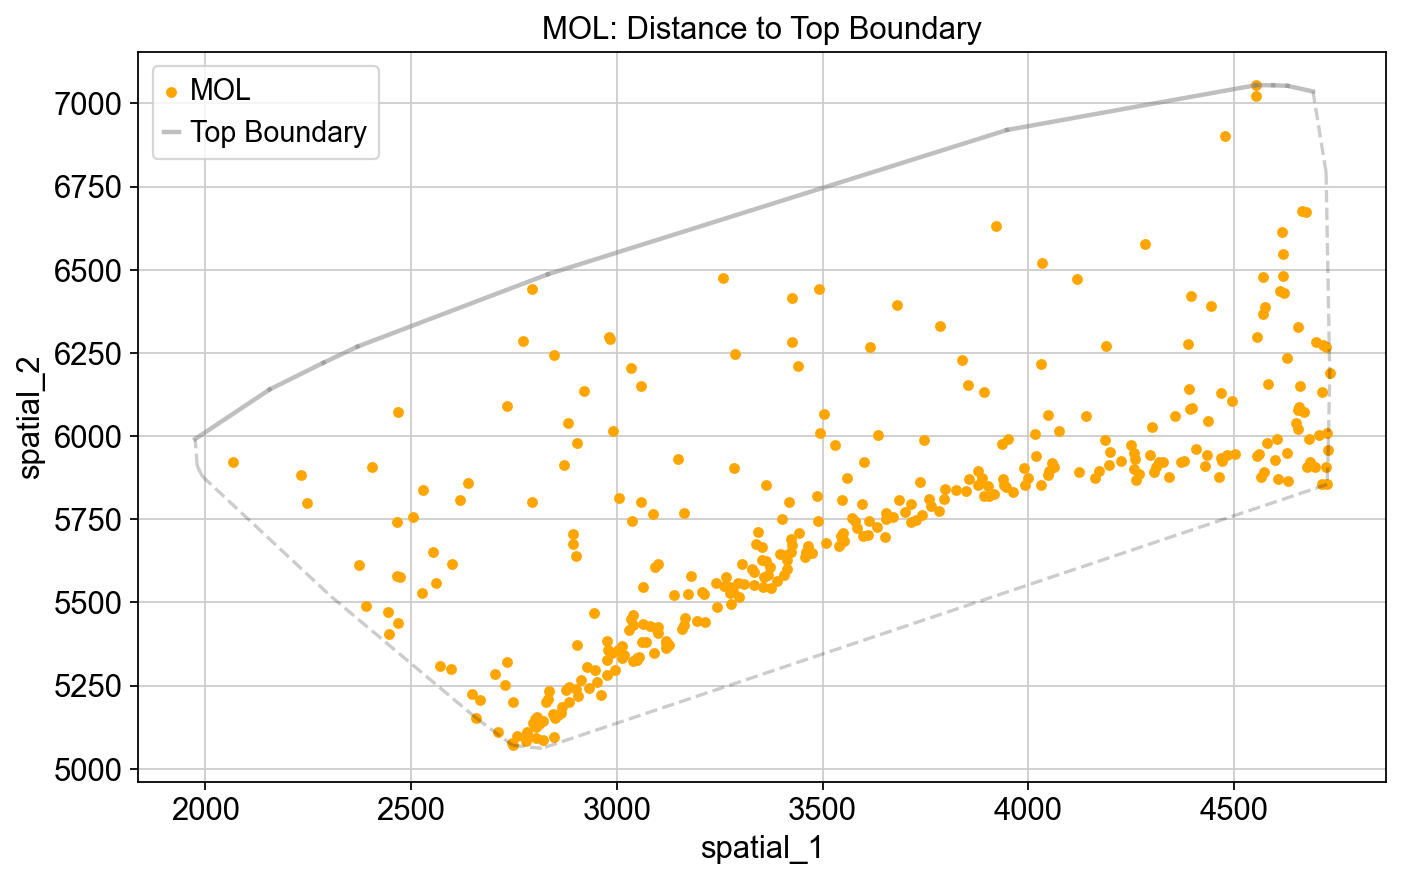

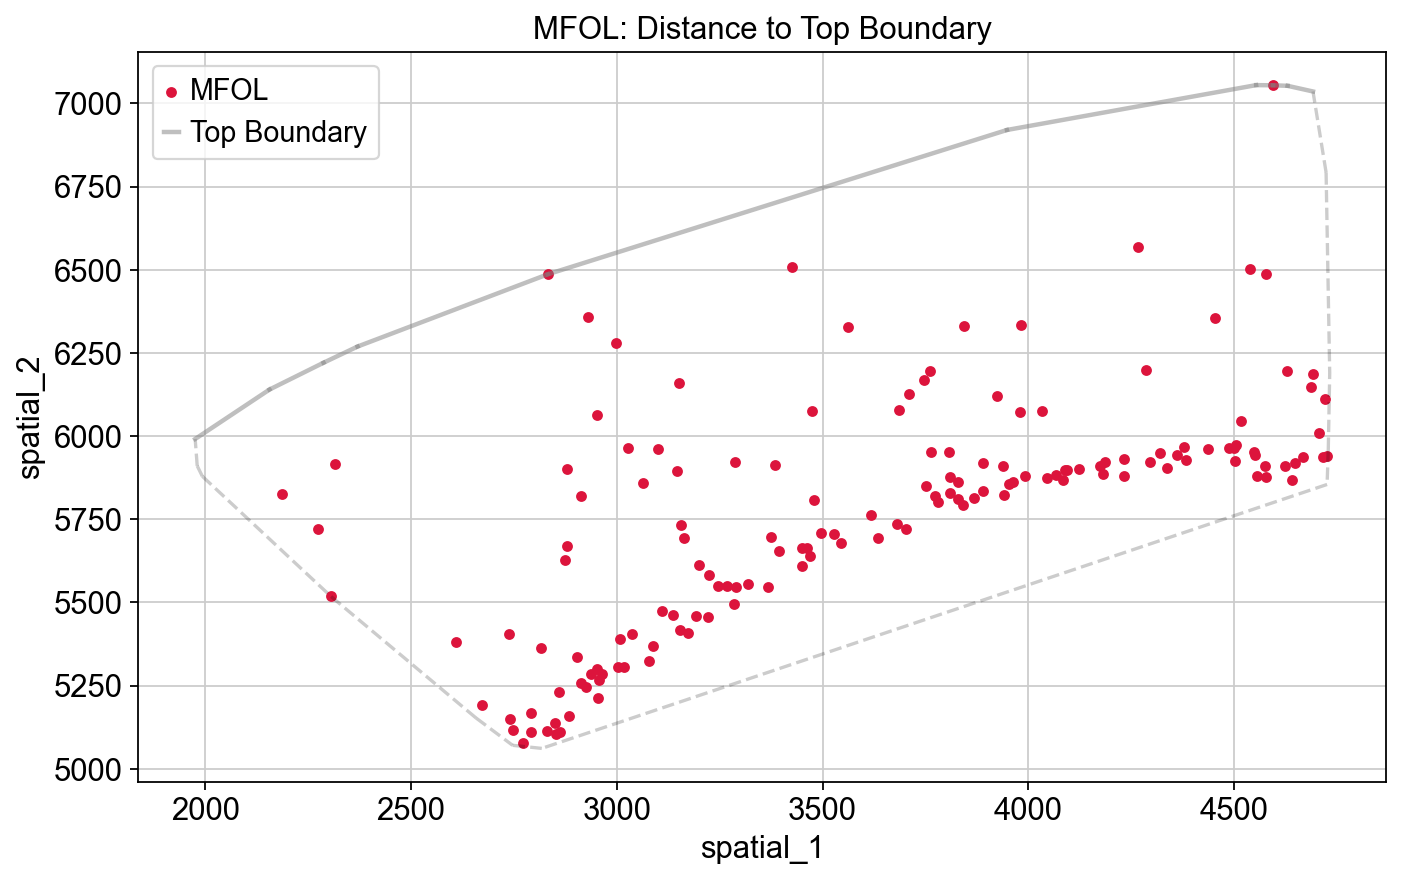

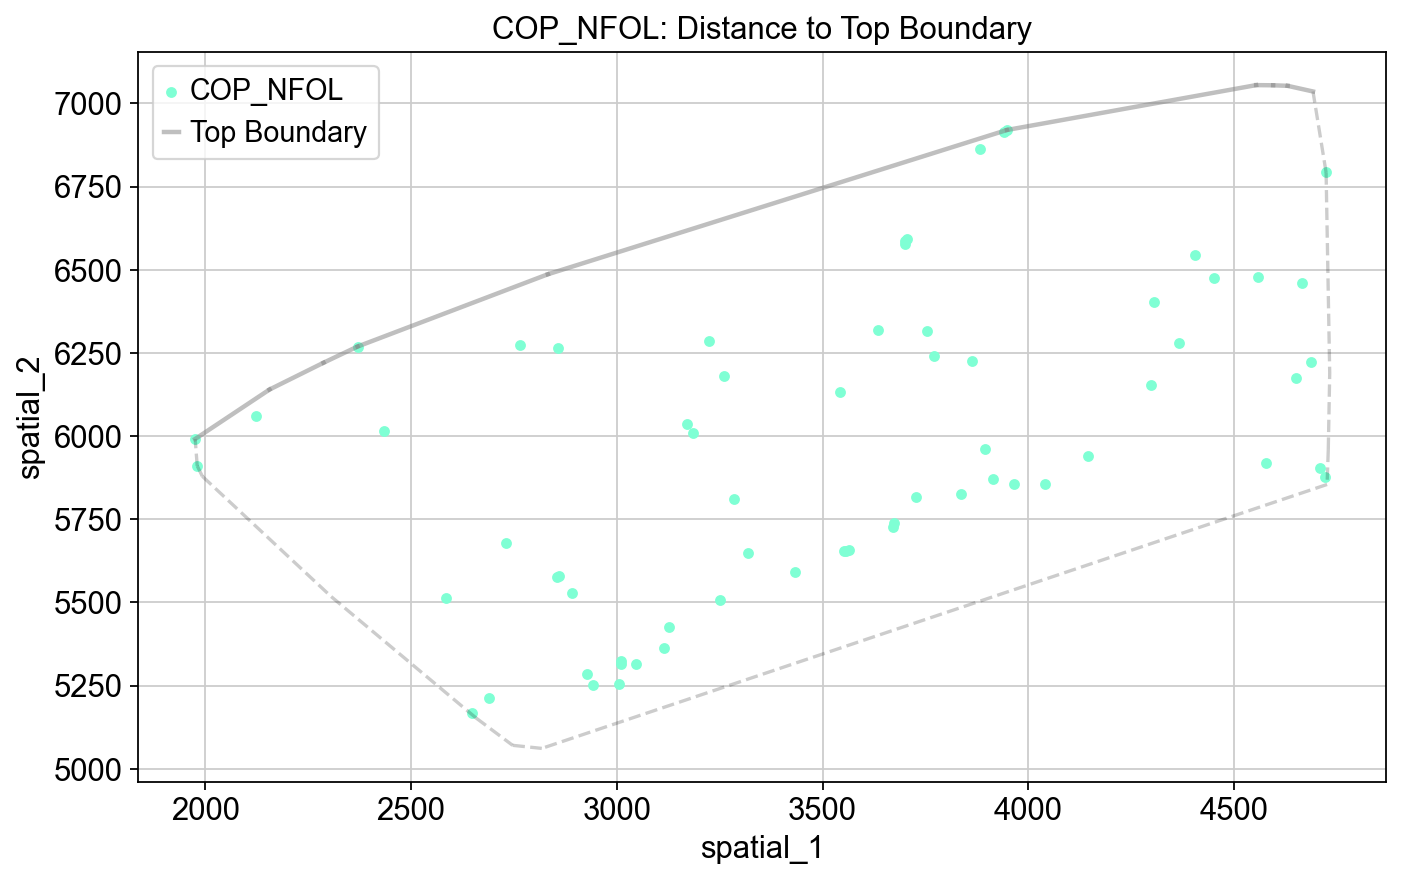

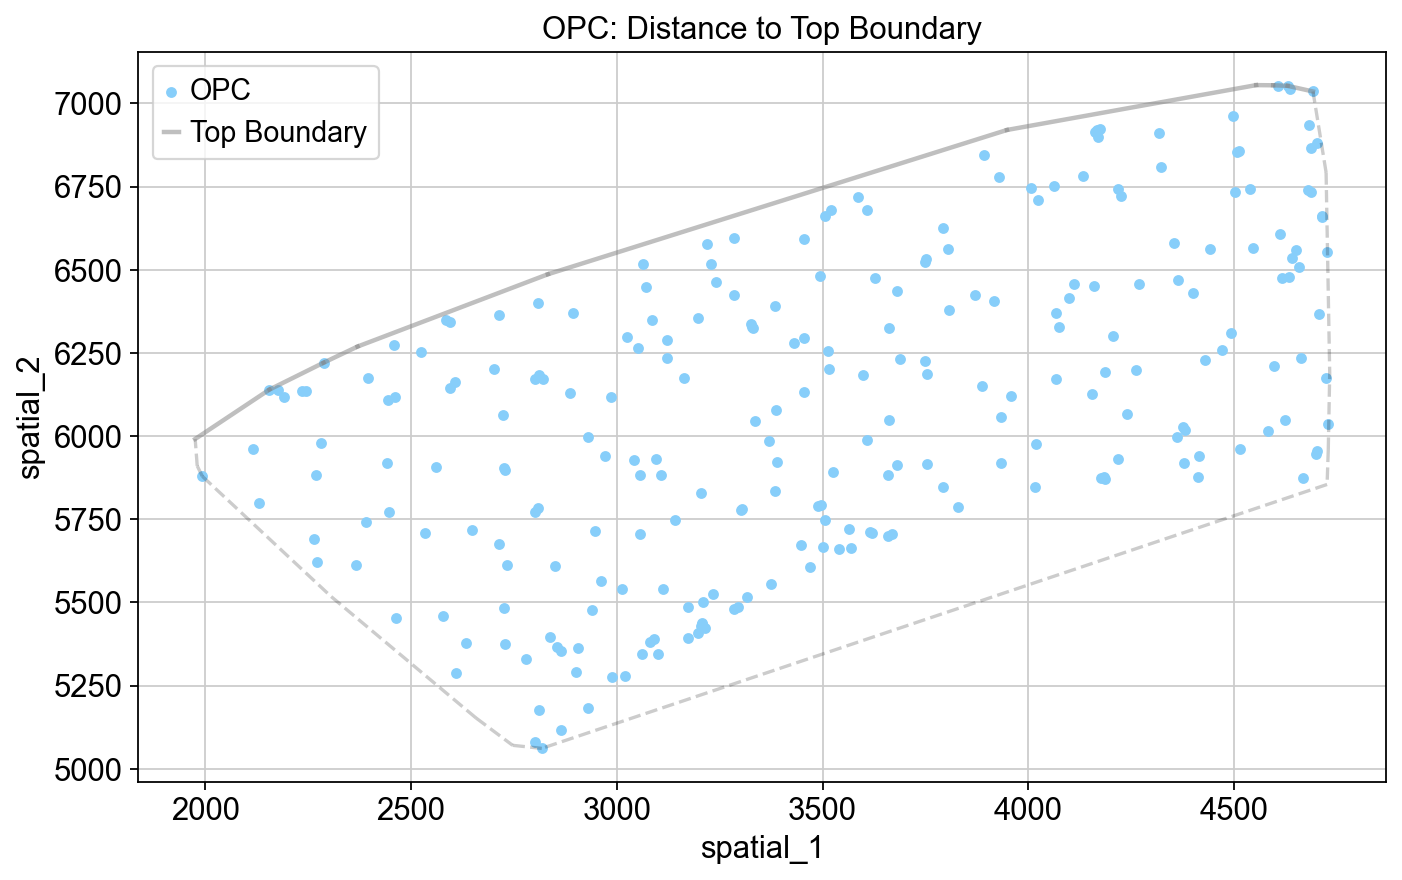

<Figure size 800x480 with 0 Axes>

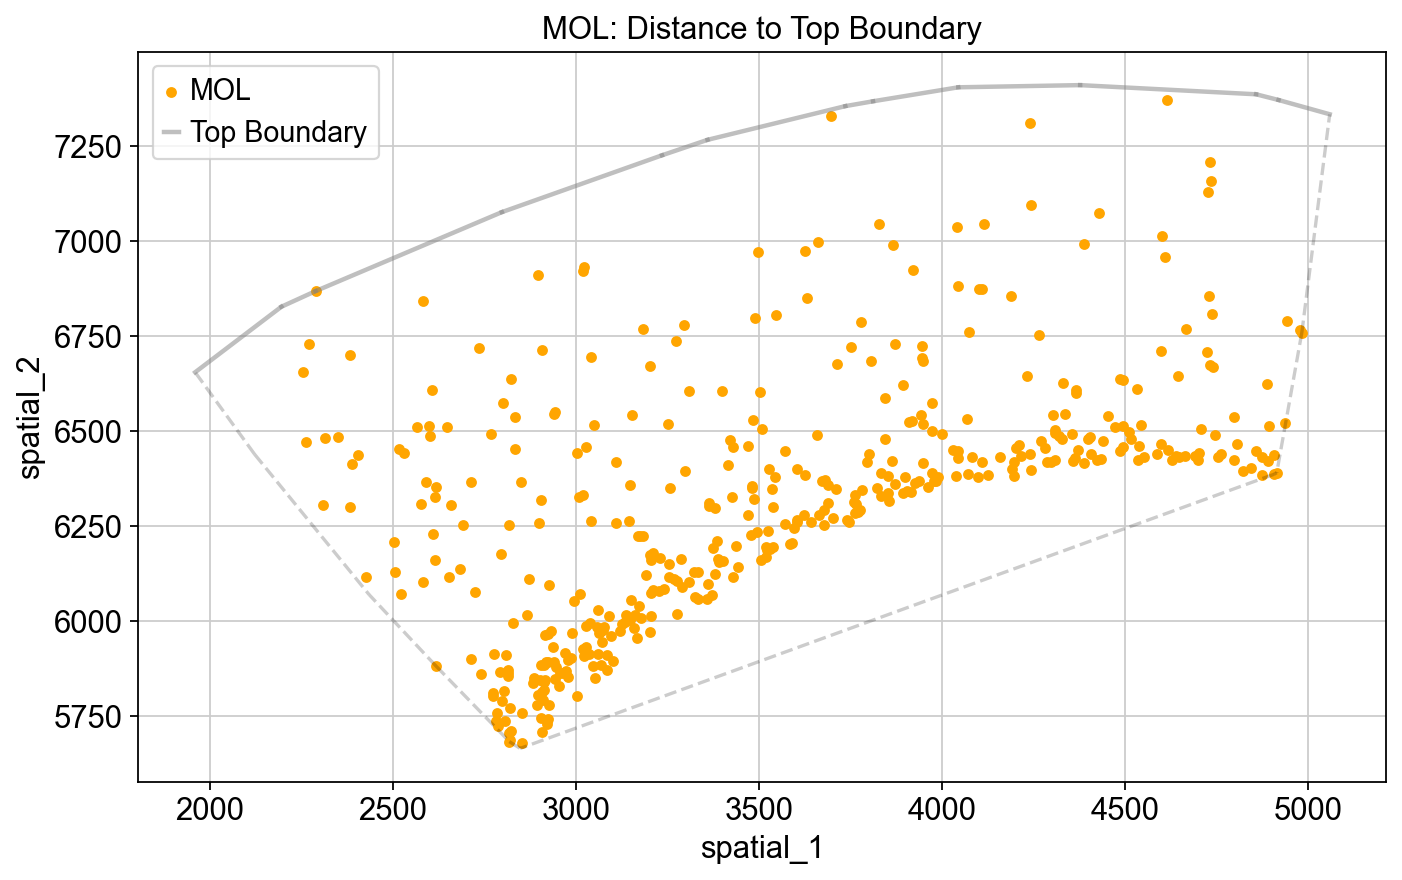

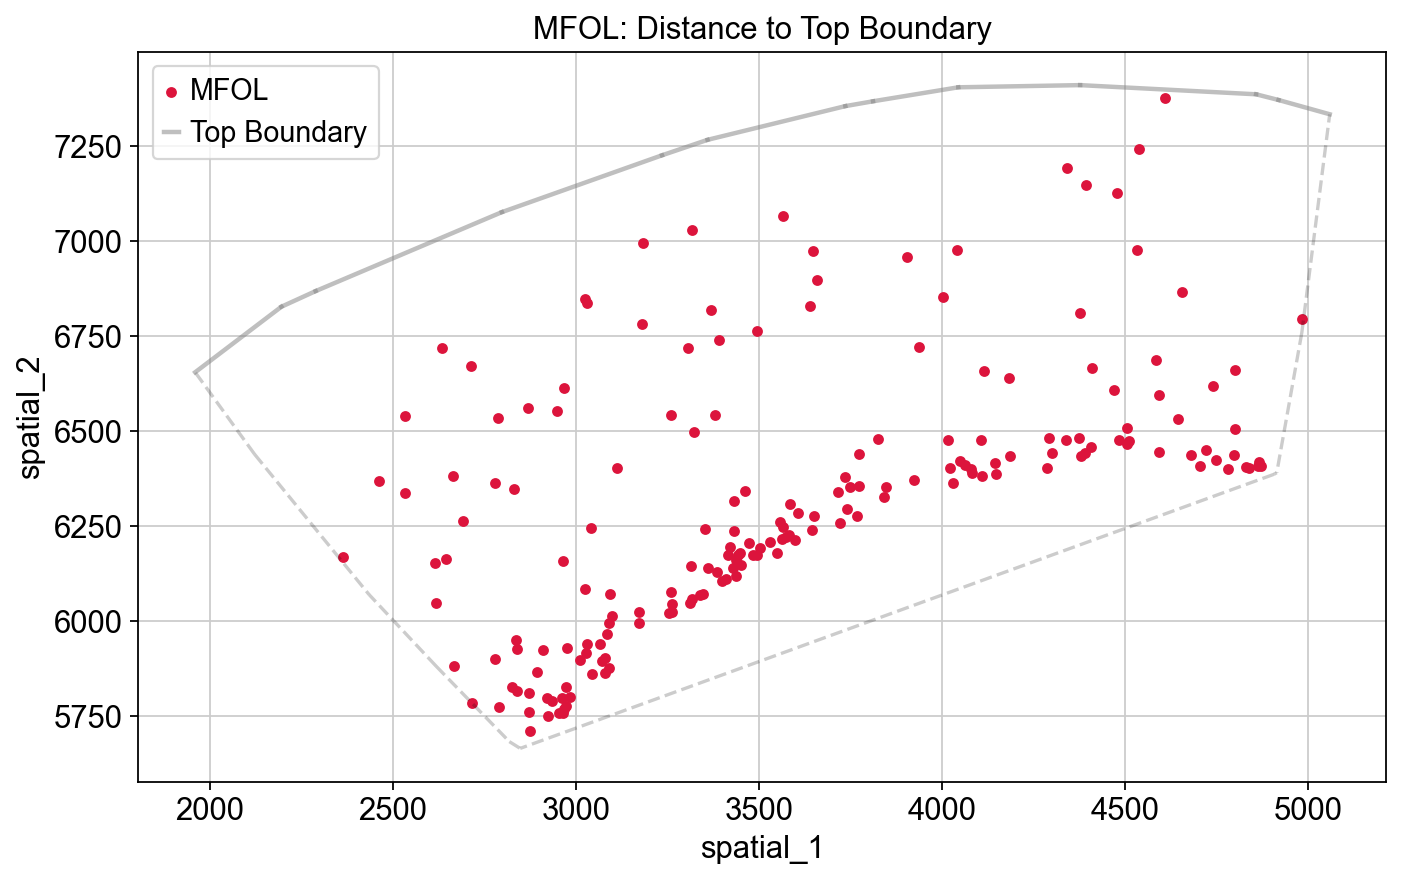

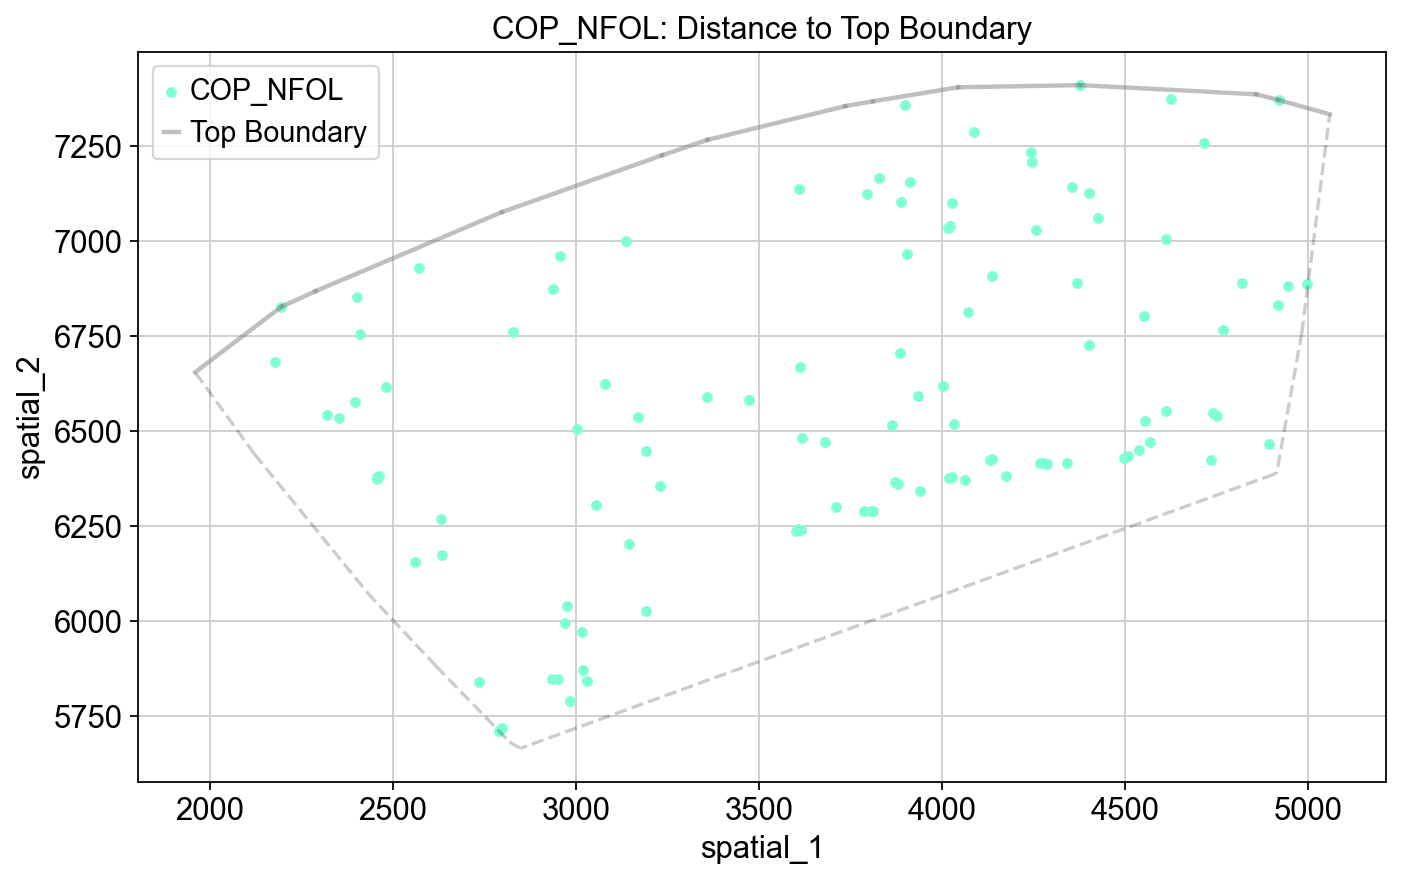

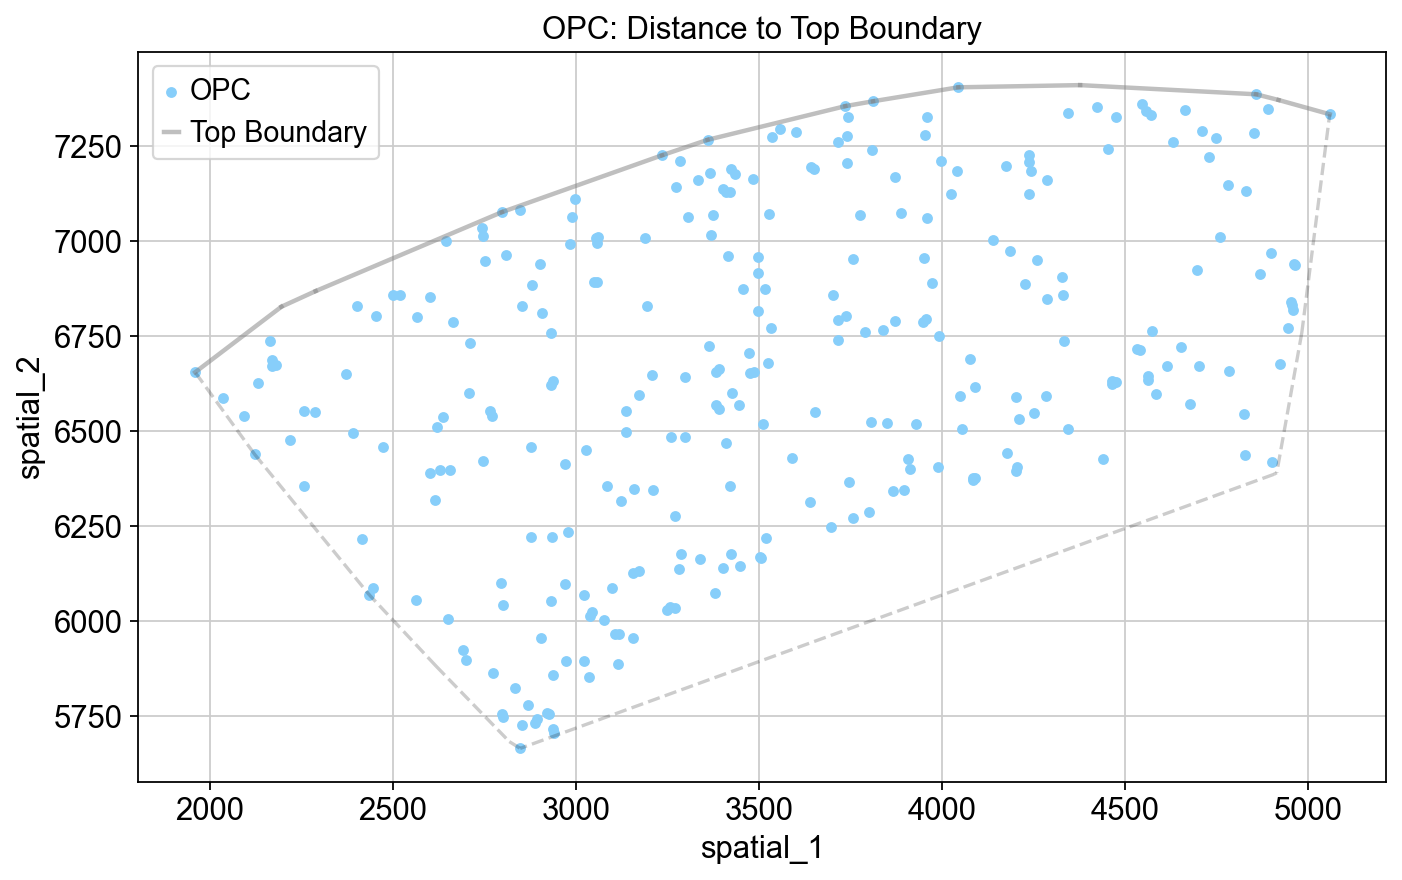

<Figure size 800x480 with 0 Axes>

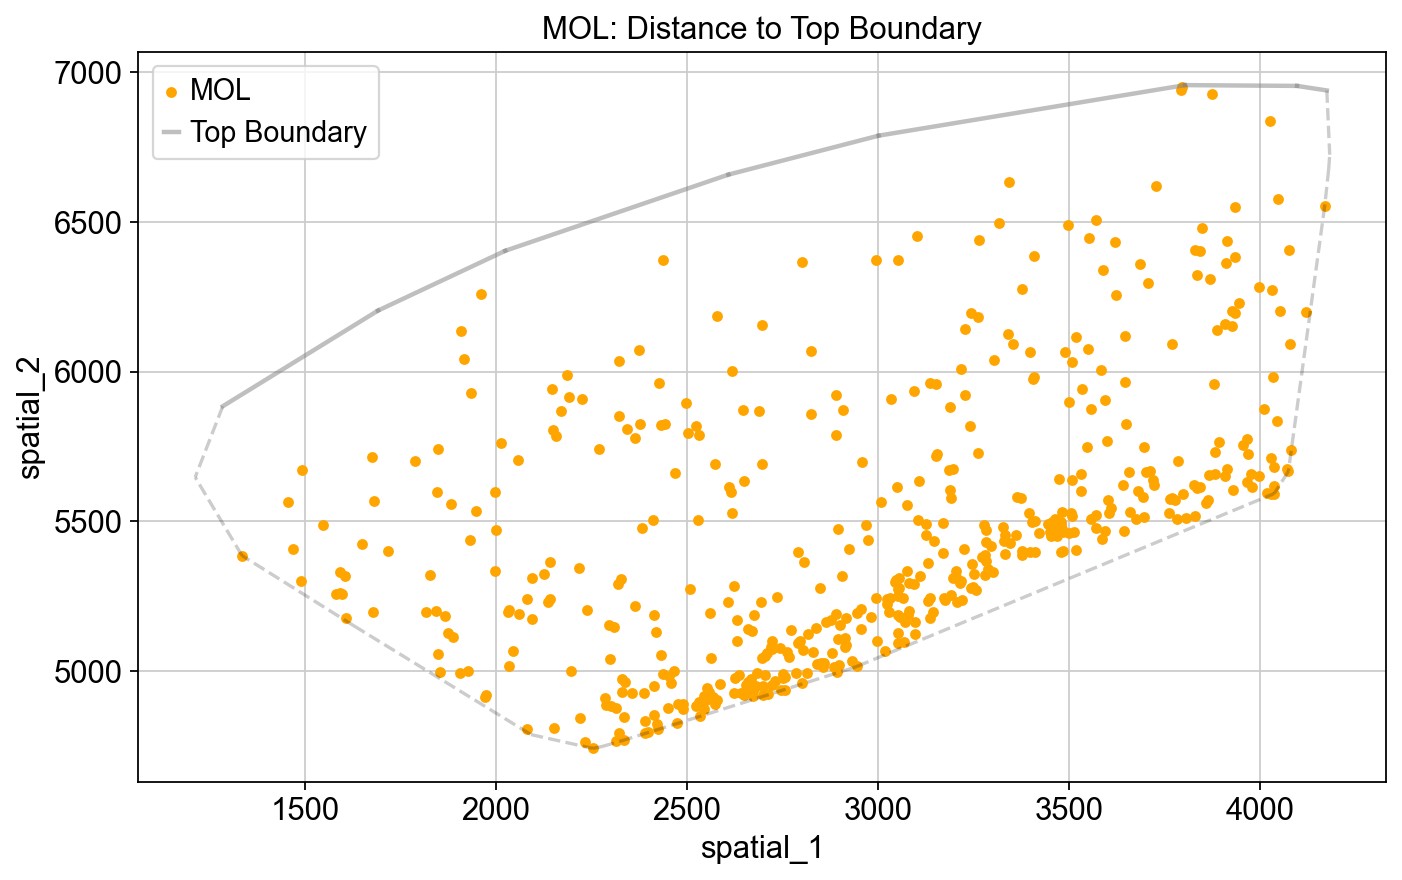

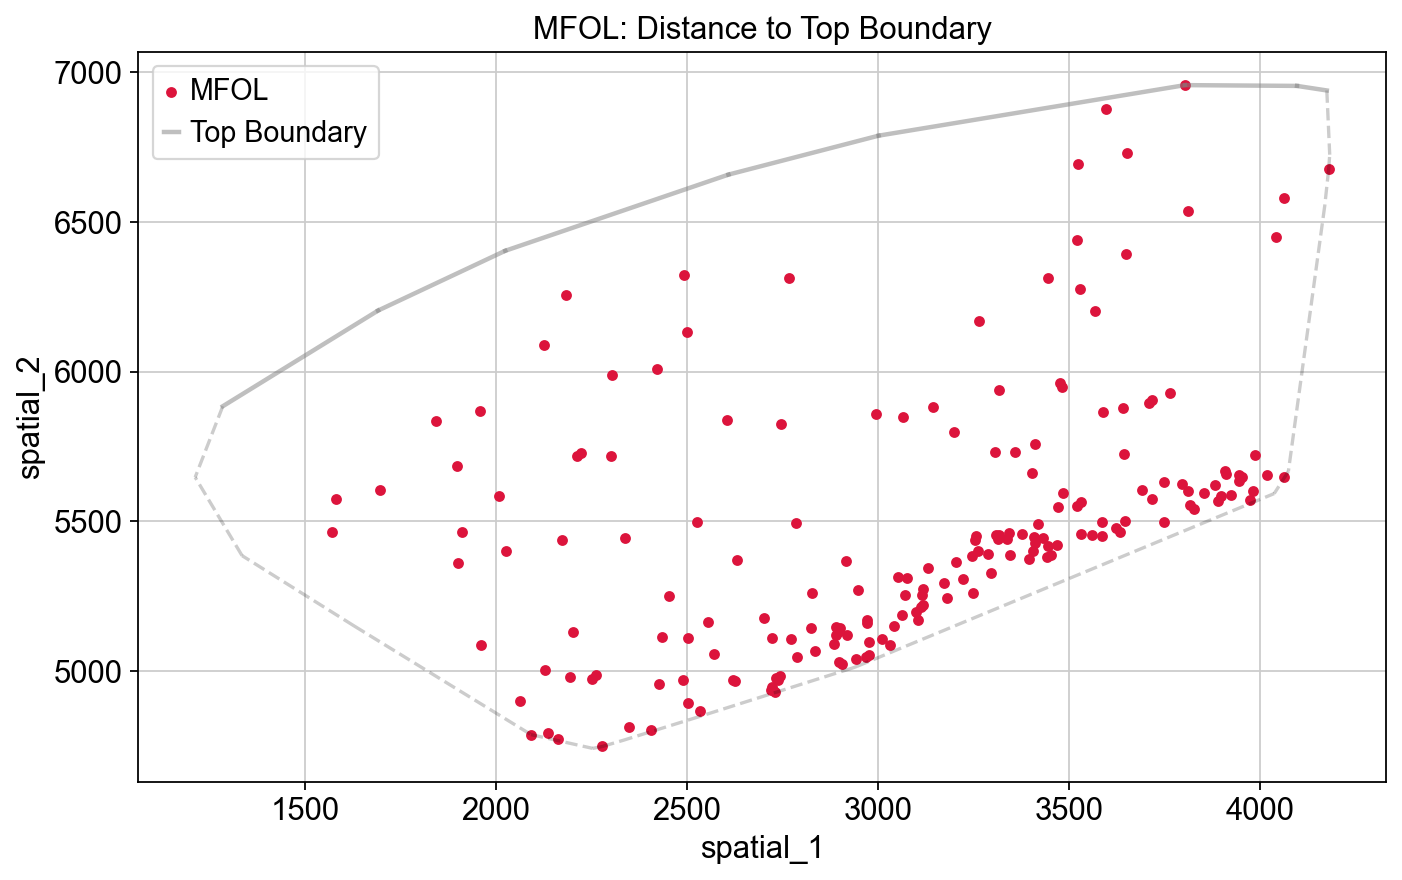

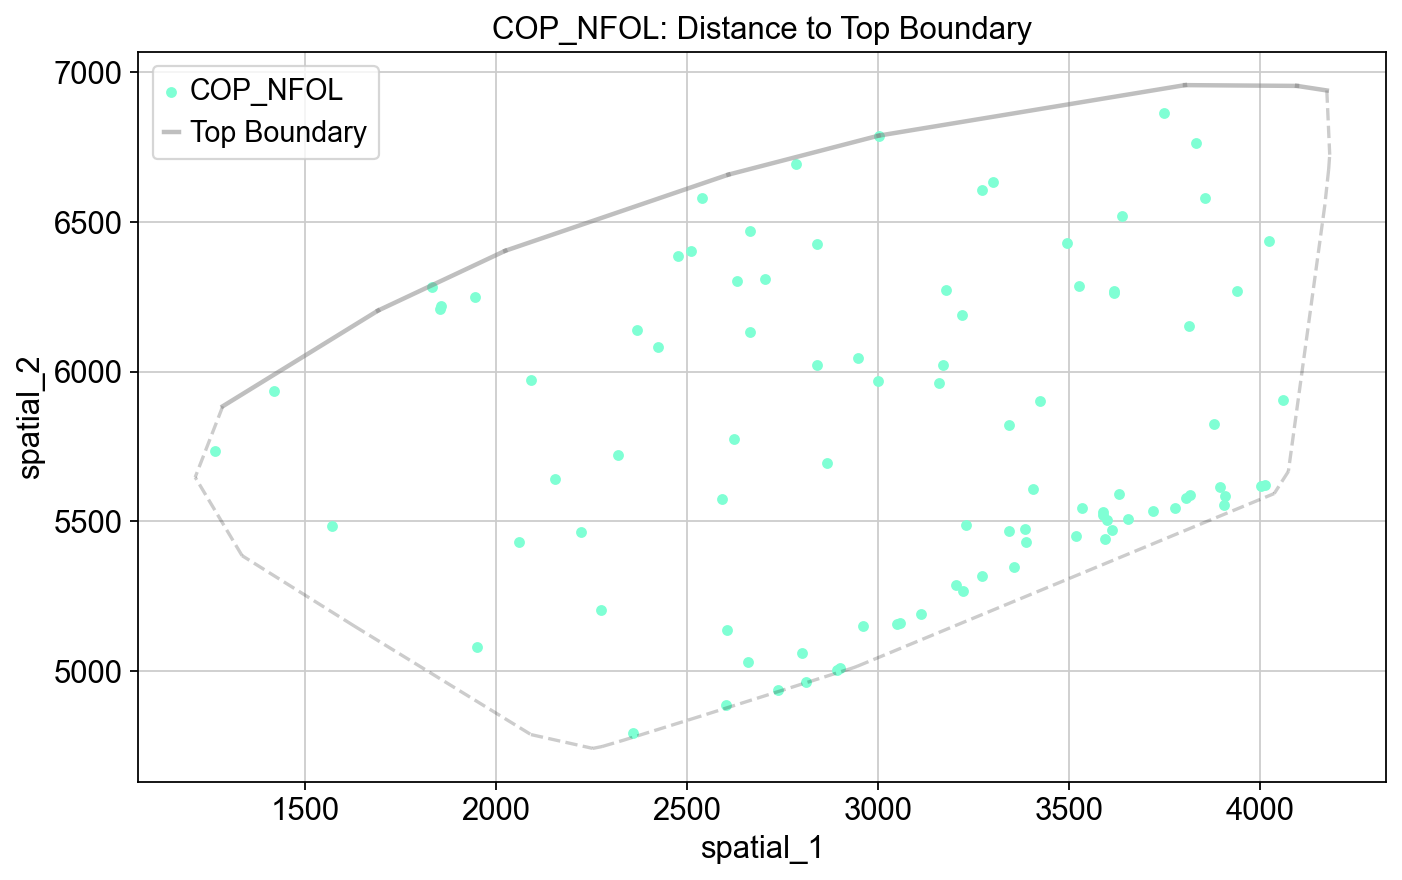

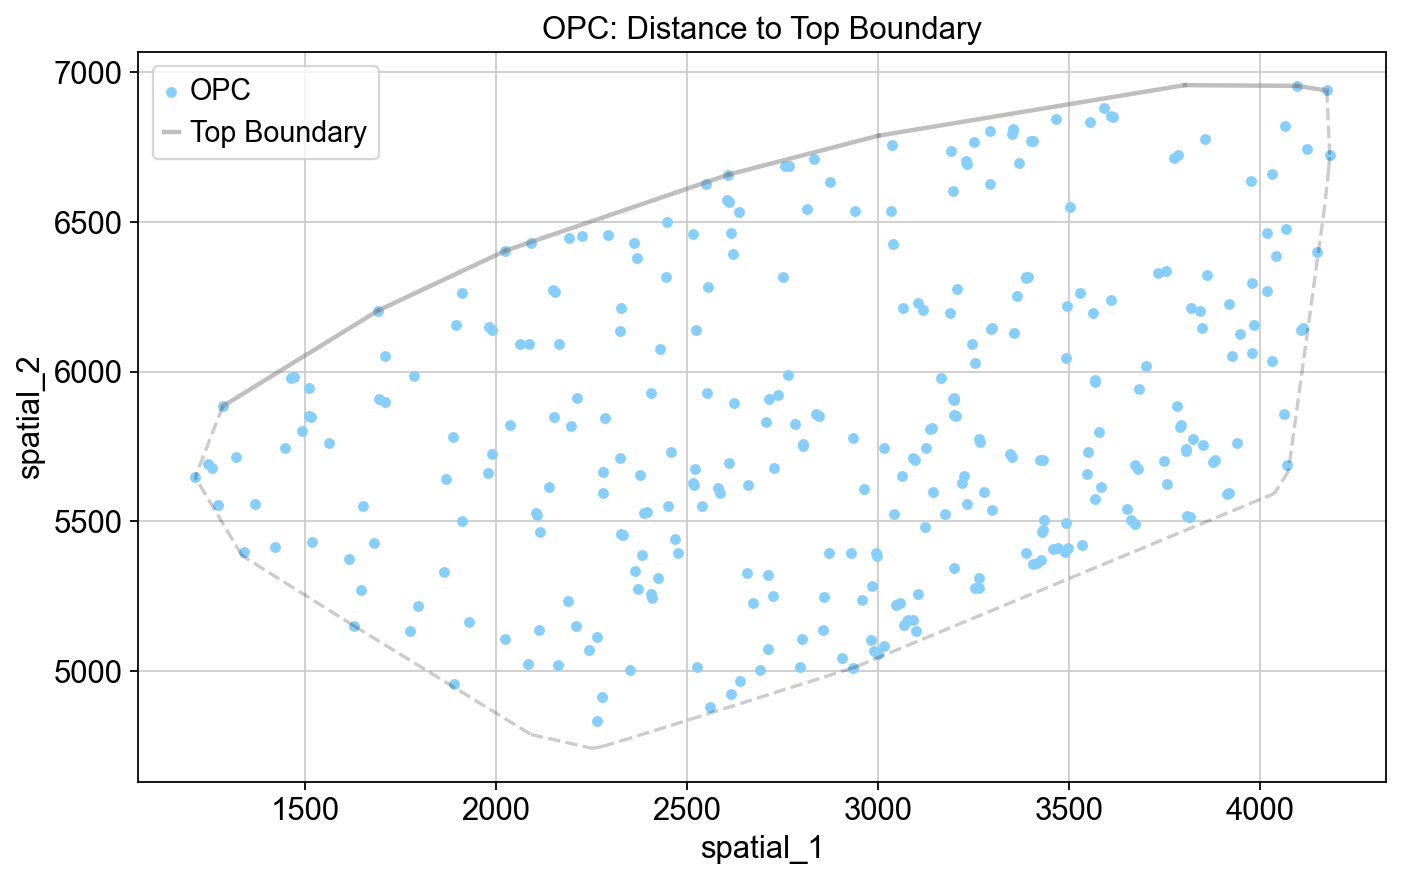

<Figure size 800x480 with 0 Axes>

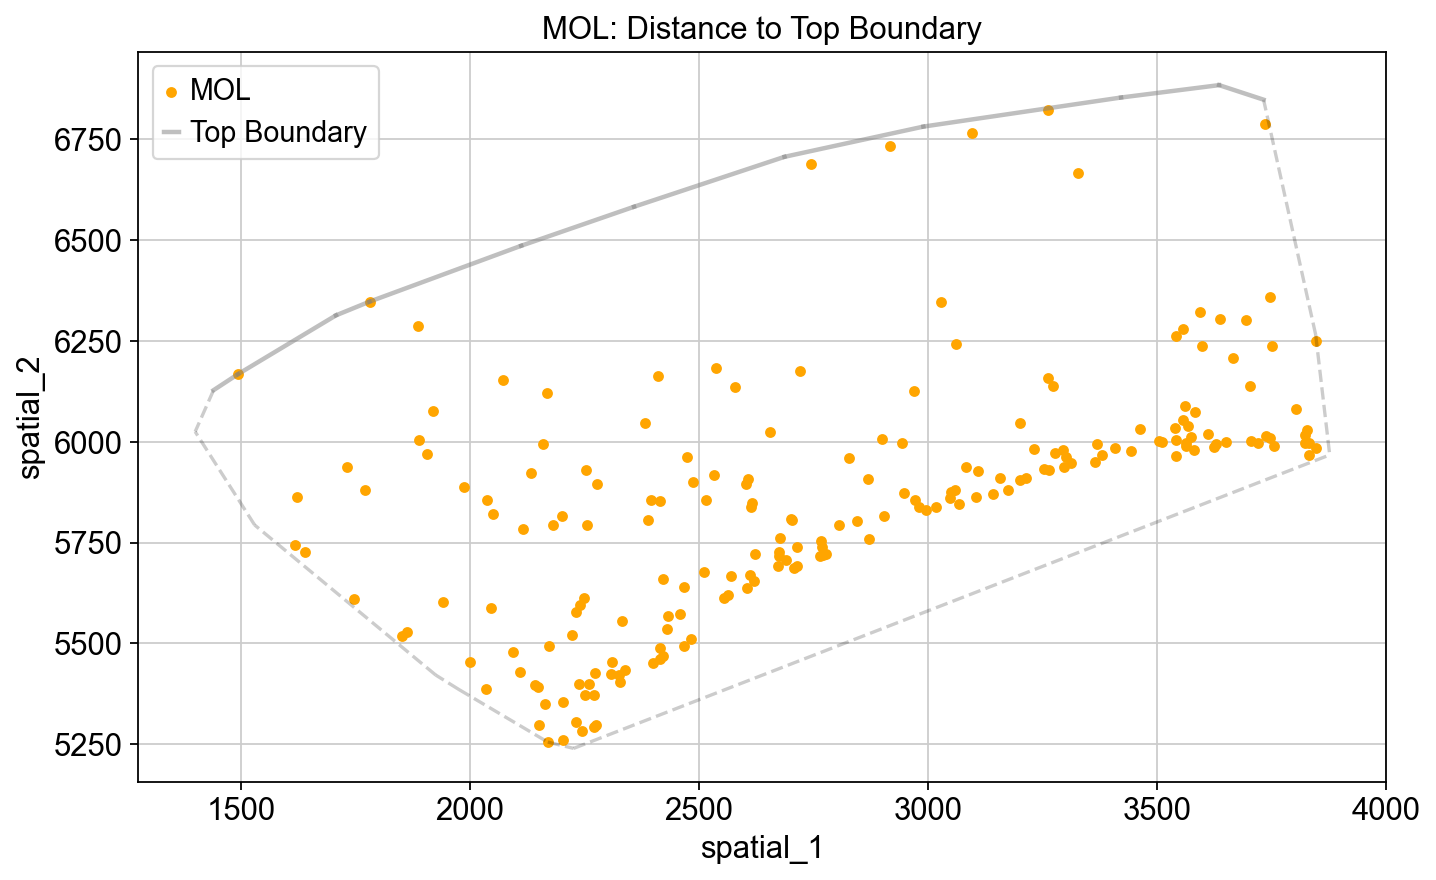

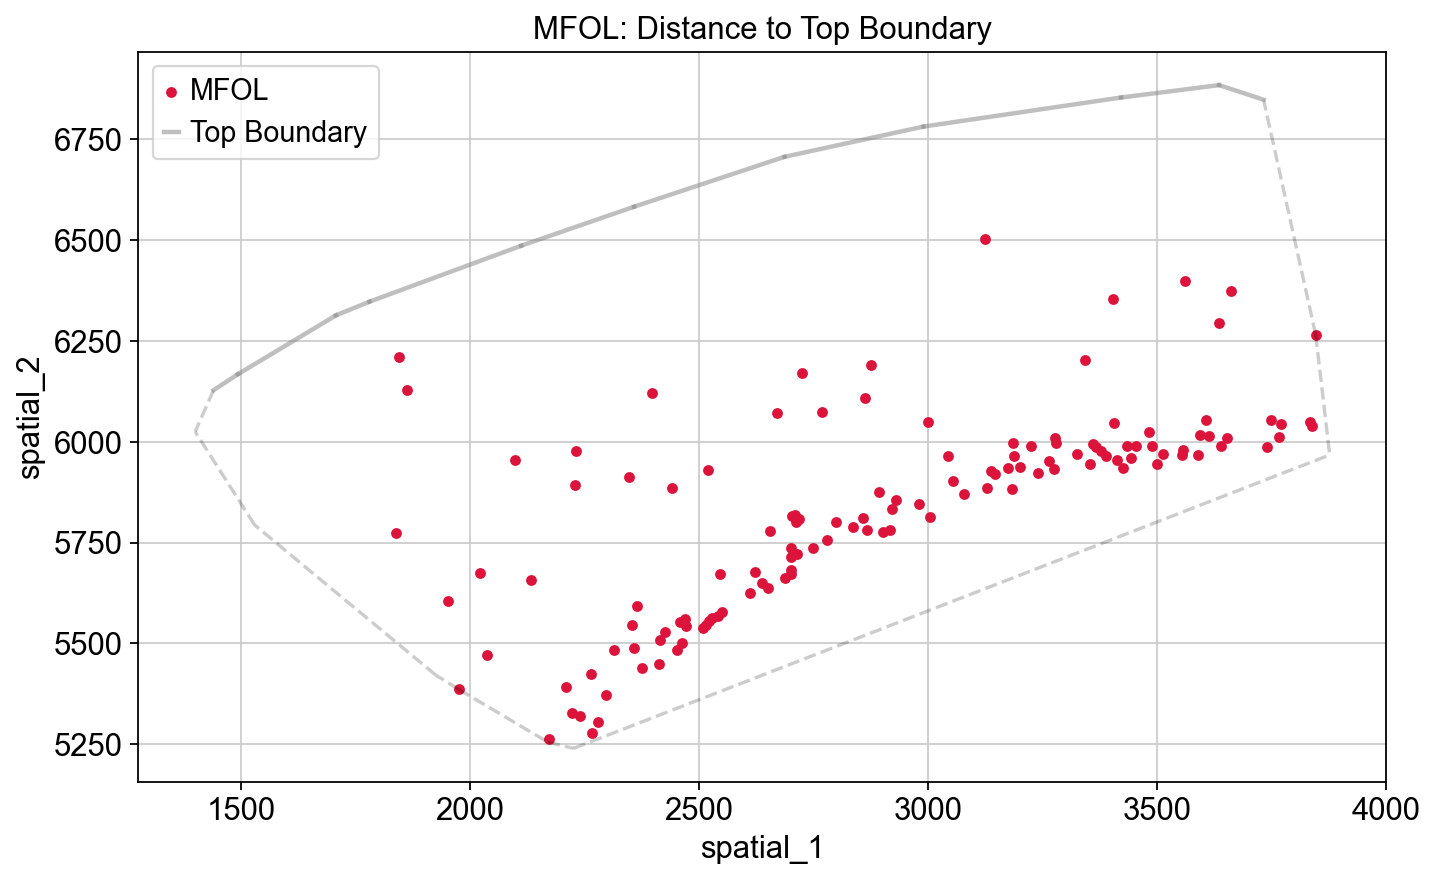

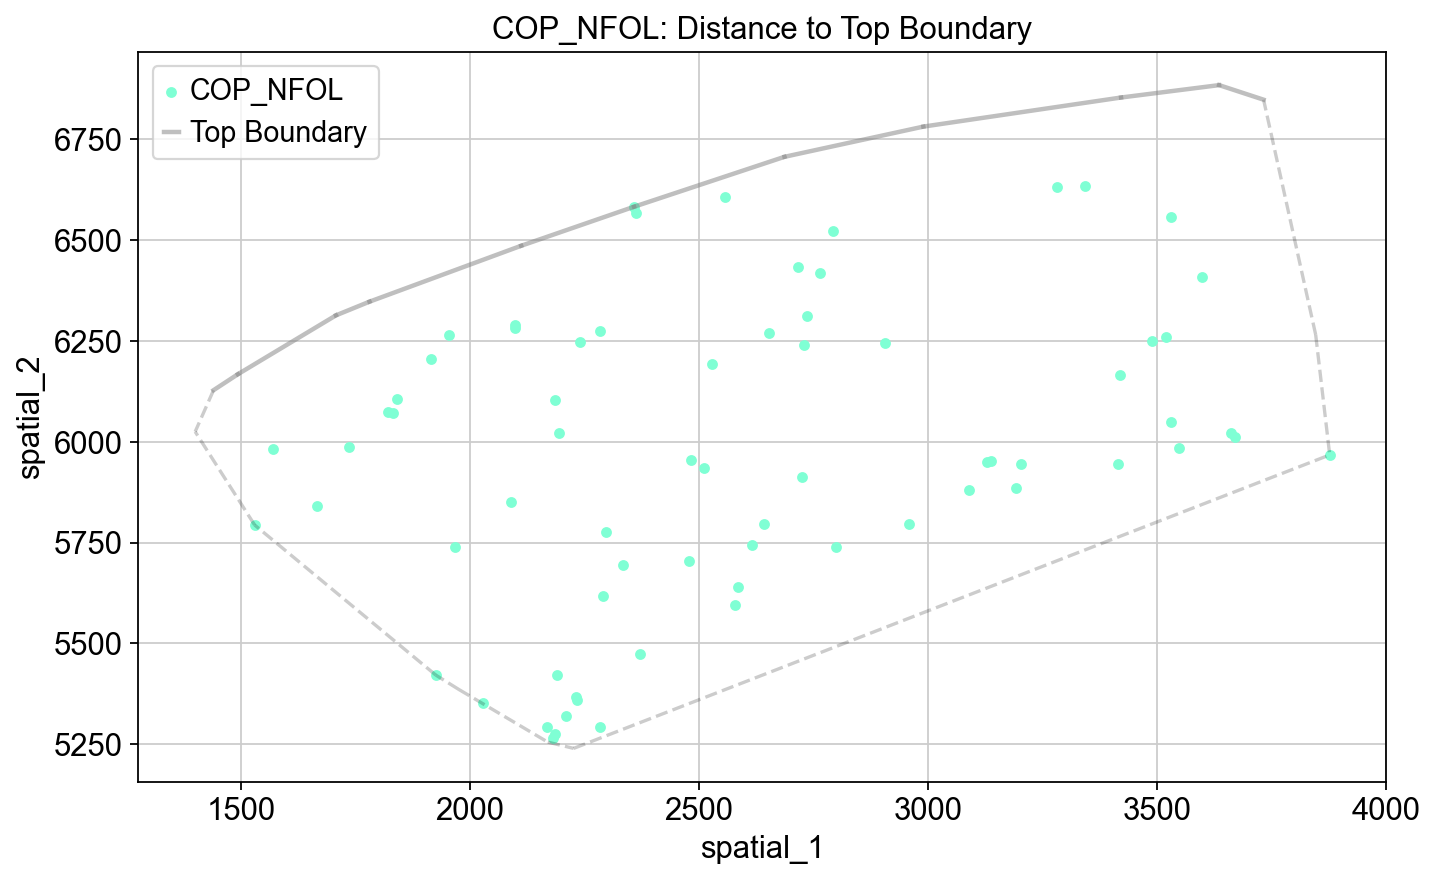

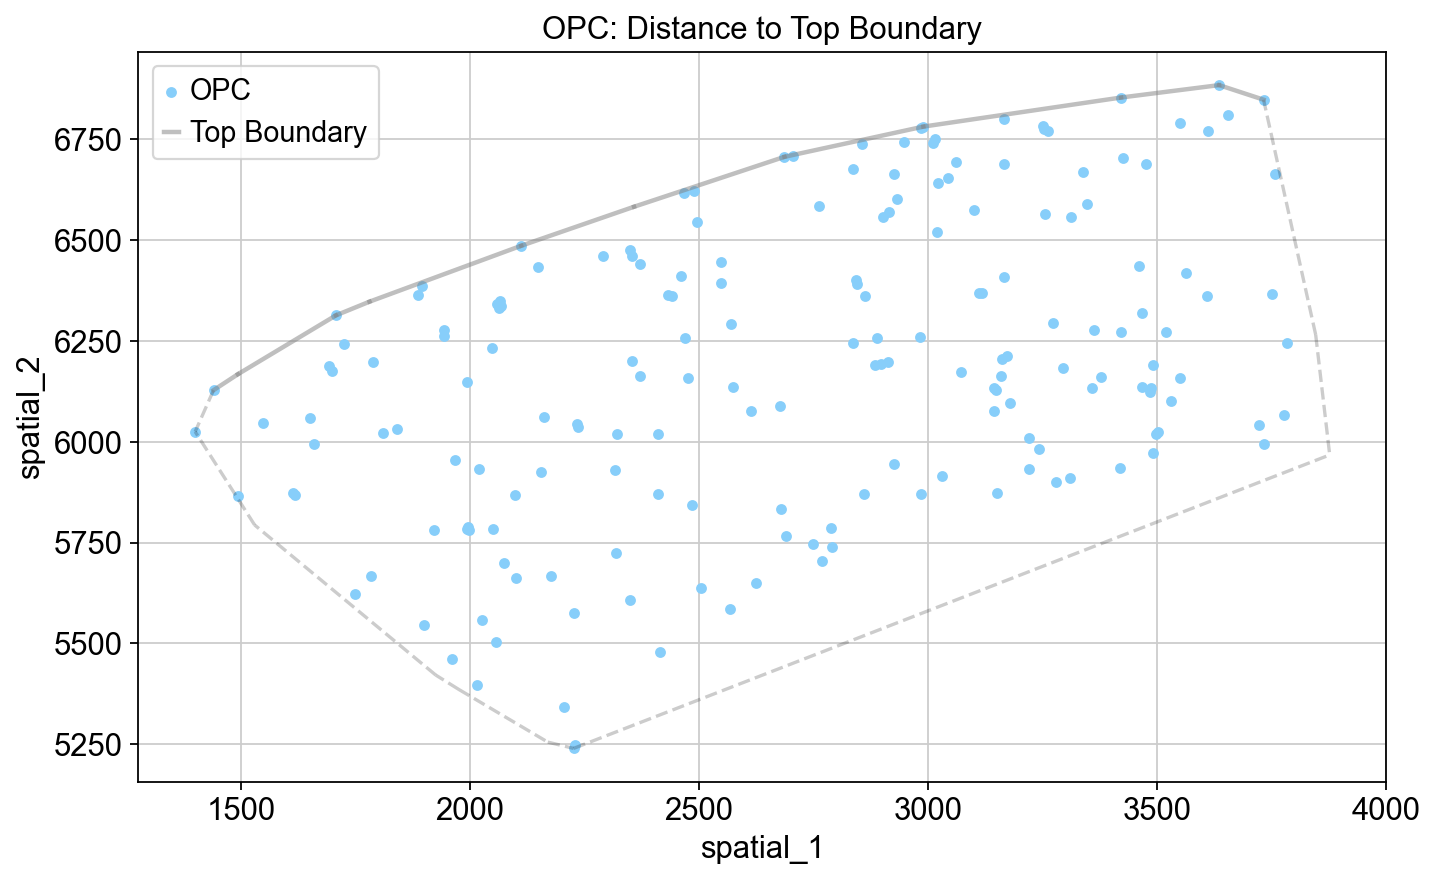

In [129]:
# Dictionary of your samples
samples = {
    "8M": puck_oligo_8M,
    "2F": puck_oligo_2F,
    "1M": puck_oligo_1M,
    "7F": puck_oligo_7F
}

# Compute distances for all samples
for name, adata in samples.items():
    samples[name] = plot_spatial_boundary_dist_all_cells(adata, adata_name=name)

In [130]:
# Define function for computing counts of each cell type in 4 equally sized bins spanning pia to corpus callosum
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_binned_proportion(adata, cell_type, obs_col='predicted_type', n_bins=4, adata_name="sample"):
    """
    Plots the proportion of cells of a given type per bin of distance to top
    and returns a DataFrame with counts for each bin.
    
    Parameters:
    - adata: AnnData object
    - cell_type: str, cell type to calculate proportion for
    - obs_col: str, column in adata.obs containing cell types
    - n_bins: int, number of equal-width bins to use
    - adata_name: str, sample identifier (for title/filename)
    
    Returns:
    - df_counts: DataFrame with counts per bin
        columns = ['bin_number', 'total_in_bin', 'count_Upper', 'count_Mid', 'count_Deep_WM']
    """
    # Get distance for all cells
    dist = adata.obs['dist_to_top']
    
    # Boolean mask for the target cell type
    is_target = adata.obs[obs_col] == cell_type
    
    # Define bins
    bins = np.linspace(dist.min(), dist.max(), n_bins + 1)
    
    # Digitize distances into bins
    bin_indices = np.digitize(dist, bins) - 1  # 0-based
    
    # Compute proportions and counts
    proportions = []
    cell_types = ['MOL', 'MFOL', 'COP_NFOL', 'OPC']
    df_counts = pd.DataFrame(0, index=np.arange(n_bins), columns=['bin_number','total_in_bin'] + [f"count_{ct}" for ct in cell_types])
    df_counts['bin_number'] = np.arange(1, n_bins+1)
    
    for i in range(n_bins):
        in_bin = bin_indices == i
        total_in_bin = np.sum(in_bin)
        df_counts.loc[i, 'total_in_bin'] = total_in_bin
        
        # Count per cell type
        for ct in cell_types:
            df_counts.loc[i, f'count_{ct}'] = np.sum((adata.obs[obs_col] == ct) & in_bin)
        
        # Proportion for the current cell type
        if total_in_bin == 0:
            proportions.append(0)
        else:
            proportions.append(100 * np.sum(is_target & in_bin) / total_in_bin)
    
    return df_counts

In [131]:
# Compute binned subtype counts per sample
samples = {'8M': puck_oligo_8M, '2F': puck_oligo_2F, '1M': puck_oligo_1M, '7F': puck_oligo_7F}
cell_types = ['MOL', 'MFOL', 'COP_NFOL', 'OPC']

counts_by_sample = {
    name: {ct: compute_binned_proportion(sample, cell_type=ct, adata_name=name)
           for ct in cell_types}
    for name, sample in samples.items()
}

In [132]:
# Combine samples to get total binned subtype counts per genotype
genotype_map = {'8M': 'WT', '2F': 'WT', '1M': 'KO', '7F': 'KO'}
genotypes = ['WT','KO']

# Prepare empty DataFrames for aggregation
combined_counts = {
    g: pd.DataFrame(0, index=np.arange(4), columns=['bin_number','total_in_bin'] + [f'count_{ct}' for ct in cell_types])
    for g in genotypes
}

for sample_name, ct_dict in counts_by_sample.items():
    g = genotype_map[sample_name]
    # Total counts per bin are the same for each cell type, so we can take the first cell type for total_in_bin
    combined_counts[g]['total_in_bin'] += ct_dict['MOL']['total_in_bin']
    combined_counts[g]['bin_number'] = ct_dict['MOL']['bin_number']
    
    # Sum counts for each cell type
    for ct in cell_types:
        combined_counts[g][f'count_{ct}'] += ct_dict[ct][f'count_{ct}']

In [133]:
from scipy.stats import chi2_contingency
import numpy as np

df_counts = pd.concat(combined_counts, names=['group']).reset_index(level=0)
print(df_counts.head(10))

df_counts = df_counts.set_index(['group', 'bin_number'])

# Reorder columns so Upper is plotted top of stack
df_counts = df_counts[['count_MOL', 'count_MFOL', 'count_COP_NFOL', 'count_OPC']]
df_prop = df_counts.div(df_counts.sum(axis=1), axis=0)

# Reshape index for grouped plotting
df_prop = df_prop.reset_index()
df_counts = df_counts.reset_index()

bins = sorted(df_prop['bin_number'].unique())
groups = ['WT', 'KO']

chi_labels = {}

for b in bins:
    sub = df_counts[df_counts['bin_number'] == b]

    wt = sub[sub['group'] == 'WT'][['count_MOL', 'count_MFOL', 'count_COP_NFOL', 'count_OPC']].values.flatten()
    ko = sub[sub['group'] == 'KO'][['count_MOL', 'count_MFOL', 'count_COP_NFOL', 'count_OPC']].values.flatten()

    contingency = np.vstack([wt, ko]).T  # layers × groups

    chi2, p, _, _ = chi2_contingency(contingency)

    chi_labels[b] = f"χ²={chi2:.1f}\np={p:.2g}"

  group  bin_number  total_in_bin  count_MOL  count_MFOL  count_COP_NFOL  \
0    WT           1           278         34          18              43   
1    WT           2           313        105          43              37   
2    WT           3           479        237          91              39   
3    WT           4           778        414         189              57   
0    KO           1           248         34          13              41   
1    KO           2           300        120          36              32   
2    KO           3           435        182          81              32   
3    KO           4           703        367         188              58   

   count_OPC  
0        183  
1        128  
2        112  
3        118  
0        160  
1        112  
2        140  
3         90  


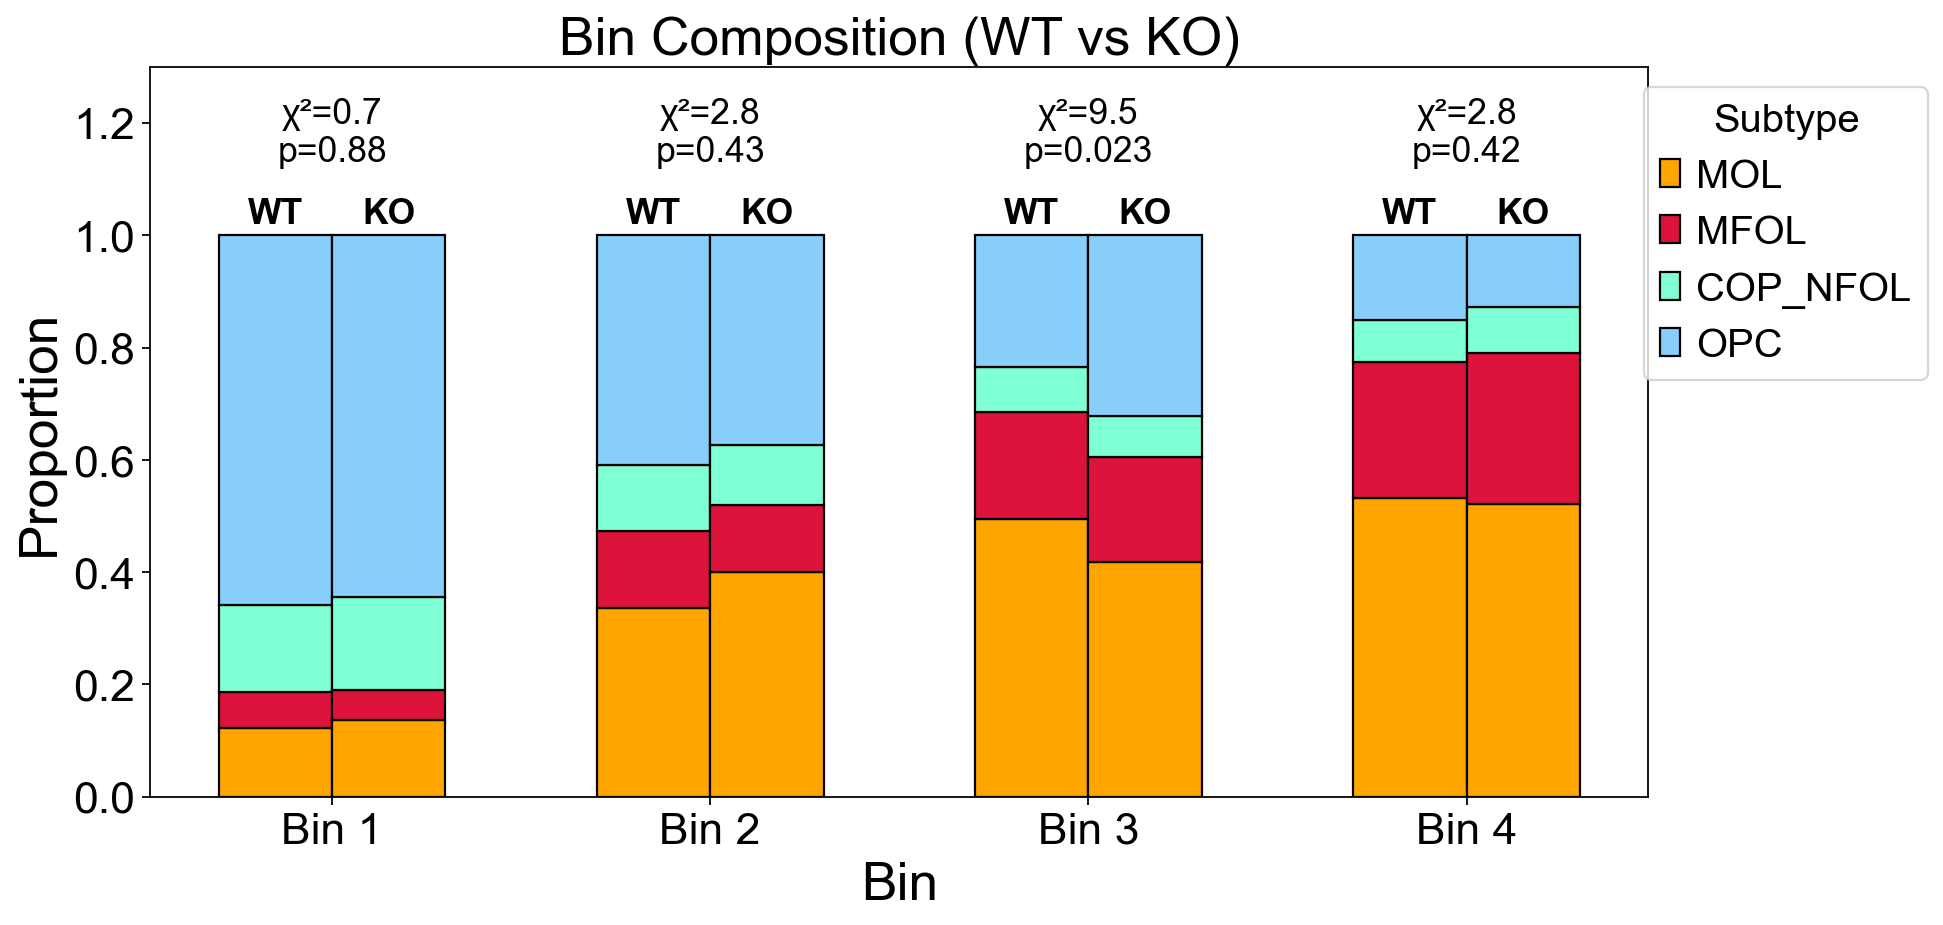

In [134]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(bins))
width = 0.3

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['orange', 'crimson', 'aquamarine', 'lightskyblue']  # MOL, MFOL, COP_NFOL, OPC

bar_tops = {}

# Loop through WT and KO
for i, group in enumerate(groups):
    dfp = df_prop[df_prop['group'] == group].set_index('bin_number').loc[bins]
    bar_tops[group] = dfp[['count_MOL', 'count_MFOL', 'count_COP_NFOL', 'count_OPC']].sum(axis=1).values
    dfc = df_counts[df_counts['group'] == group].set_index('bin_number').loc[bins]

    bottoms = np.zeros(len(bins))

    # WT / KO labels above bars
    xpos = x + (i - 0.5) * width
    heights = bar_tops[group]

    for xi, h in zip(xpos, heights):
        ax.text(
            xi,
            h + 0.01,   # small offset above bar
            group,
            ha='center',
            va='bottom',
            fontsize=16,
            fontweight='bold'
        )

    for j, col in enumerate(['count_MOL', 'count_MFOL', 'count_COP_NFOL', 'count_OPC']):
        bars = ax.bar(
            x + (i - 0.5) * width,
            dfp[col],
            width,
            bottom=bottoms,
            edgecolor='black', linewidth=1,
            label=f"{group} {col}" if i == 0 else "",
            color=colors[j]
        )
        bottoms += dfp[col].values

# Formatting
ax.set_xticks(x)
ax.set_xticklabels([f"Bin {b}" for b in bins])
ax.tick_params(axis='both', labelsize=20)

ax.set_xlabel("Bin", fontsize=24)
ax.set_ylabel("Proportion", fontsize=24)
ax.set_title("Bin Composition (WT vs KO)", fontsize=24)

ax.set_ylim(0, 1.1)

ax.grid(False)

# Cleaner legend (only layers, not duplicated WT/KO)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:4], ['MOL', 'MFOL', 'COP_NFOL', 'OPC'],
          bbox_to_anchor=(1.2, 1), loc='upper right', fontsize=18, title='Subtype', title_fontsize=18)

for i, b in enumerate(bins):
    # center between WT and KO bars
    x_center = x[i]

    # find max height of either WT or KO stack (should be ~1.0)
    y_top = 1.12
    ax.set_ylim(0, 1.3)

    ax.text(
        x_center,
        y_top,
        chi_labels[b],
        ha='center',
        va='bottom',
        fontsize=16
    )

#plt.tight_layout(pad=3)   # increase padding

plt.savefig(f"{parent_dir}/plots/oligo_binned_barplot_stacked.pdf", dpi=300)  # save as PDF
plt.show()